In [1]:
import context
from IPython.display import Image
import IPython.display as display
# import plotting package and numerical python package for use in examples later
import matplotlib.pyplot as plt
# import the numpy array handling library
import numpy as np
# import the pde solver for a simple 1-d tank of water with a drop of rain
import adv_dif_1D_bott
import importlib
import matplotlib.colors as colors
import matplotlib.cm as cmx
import matplotlib.colorbar as colorbar

******************************
context imported. Front of path:
/home/jovyan
back of path: /opt/conda/lib/python3.13/site-packages
******************************

through /home/jovyan/Numeric/Group_project/context.py


In [3]:
importlib.reload(adv_dif_1D_bott)

L=20
T=60
n_grid = 77
n_time = 59
dx = L / (n_grid+3)
dt = T / (n_time+1)
x = np.linspace(0,L,n_grid)
t = np.linspace(0,T,n_time)
c=adv_dif_1D_bott.adv_dif_1D([n_grid, n_time, L, T])

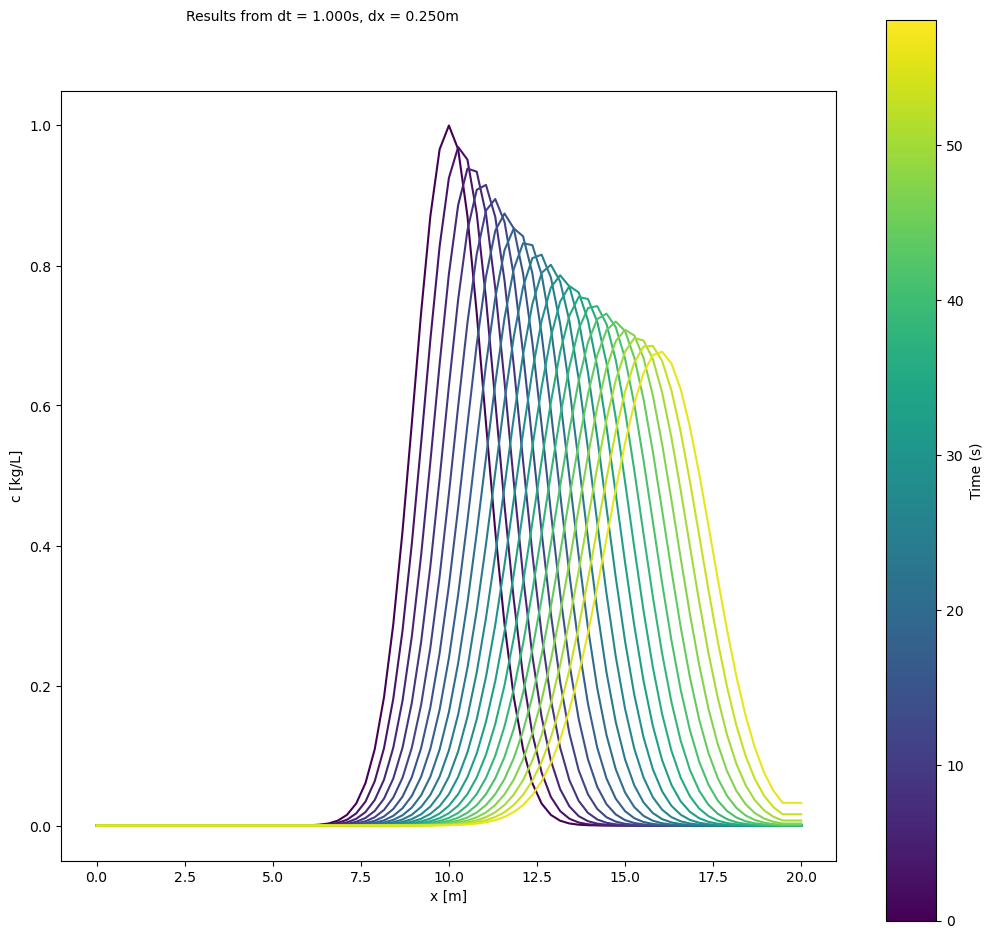

In [4]:
fig, ax_c = plt.subplots(1,1, figsize=(10,10))
the_title = fig.text(0.25, 0.95, 'Results from dt = %.3fs, dx = %.3fm' % (dt, dx))
ax_c.set_ylabel('c [kg/L]')
ax_c.set_xlabel('x [m]')

# We use color to differentiate lines at different times.  Set up the color map
cmap = plt.get_cmap('viridis')
cNorm  = colors.Normalize(vmin=0, vmax=1.*n_time)
cNorm_inseconds = colors.Normalize(vmin=0, vmax=1.*(n_time-1)*dt)
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cmap)

# Only try to plot 20 lines, so choose an interval if more than that (i.e. plot every interval lines)
interval = int(np.ceil(n_time/20))

# Do the main plot
for time in range(0, n_time, interval):
    colorVal = scalarMap.to_rgba(time)
    ax_c.plot(x,c[time, 2:n_grid+2], color=colorVal)

# Add the custom colorbar
ax_c = fig.add_axes([0.95, 0.05, 0.05, 0.9])
cb1 = colorbar.ColorbarBase(ax_c, cmap=cmap, norm=cNorm_inseconds)
cb1.set_label('Time (s)')